# Study Jam ML — Chapter 3 (Challenge)

---

## Beat the Baseline + Save & Use Your Model

**Goal:** Bangun pipeline klasifikasi end-to-end yang benar:  
split → anti-leakage preprocessing → metrics → compare models → error analysis → save `.joblib` → predict test.

### Dataset
- `ps_train.csv` (train + target `satisfaction`)
- `ps_test.csv` (test tanpa label untuk prediksi)

> Kerjakan berurutan. Isi semua bagian bertanda **`# TODO`**.

In [2]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# Part 1: Download + Load + Split (Stratify)

**Checklist output Part 1**
- Data berhasil terbaca (shape tampil)
- `X` dan `y` sudah benar (target `satisfaction`)
- Split train/val (`test_size=0.2`, `random_state=42`, `stratify=y`)
- Rasio kelas train vs val terlihat mirip

In [3]:
# Download dataset (do not edit)
!wget -q -O ps_train.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_train.csv
!wget -q -O ps_test.csv  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_test.csv

print("Files:", [p.name for p in Path('.').glob('ps_*.csv')])

Files: ['ps_train.csv', 'ps_test.csv']


In [4]:
# Load train
df = pd.read_csv("ps_train.csv")
print("Train shape:", df.shape)
display(df.head())

Train shape: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## Part 1.1 — Define target (y) and features (X)

**Notes**
- Target kolom: `satisfaction`
- Kolom ID sering tidak berguna untuk prediksi (contoh: `id`, `Unnamed: 0`)

Isi cell berikut (lihat TODO).

In [5]:
# TODO: set target column name
TARGET_COL = "satisfaction"

# TODO: define ID-like columns to drop (if any)
id_like = [c for c in df.columns if c.lower() in ["id", "unnamed: 0"]]
print("Kolom ID yang akan di-drop:", id_like)

# TODO: create X and y
X = df.drop(columns=[TARGET_COL] + id_like, errors="ignore")
y = df[TARGET_COL]

print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", y.unique())

Kolom ID yang akan di-drop: ['Unnamed: 0', 'id']
X shape: (103904, 22) | y shape: (103904,)
Classes: ['neutral or dissatisfied' 'satisfied']


## Part 1.2 — Sanity checks (wajib tampil)

Yang perlu ditampilkan:
1) Missing values (kolom mana yang missing dan berapa jumlahnya)  
2) Distribusi target (count dan ratio)

In [6]:
# TODO: show missing values summary (only columns with missing > 0)
missing = X.isna().sum().sort_values(ascending=False)
print("=== Missing Values ===")
display(missing[missing > 0].to_frame("missing_count"))

# TODO: show target distribution (count + ratio)
counts = y.value_counts()
print("\n=== Target Distribution ===")
display(counts.to_frame("count"))
display((counts / counts.sum()).round(4).to_frame("ratio"))

=== Missing Values ===


,missing_count
Arrival Delay in Minutes,310



=== Target Distribution ===


,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


,ratio
satisfaction,
neutral or dissatisfied,0.5667
satisfied,0.4333


## Part 1.3 — Split train/validation (stratify)

Pastikan `stratify=y` dipakai.

In [7]:
# TODO: split train/validation with stratify
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "| Val:", X_val.shape)
print("\nTrain ratio:\n", y_train.value_counts(normalize=True).round(4))
print("\nVal ratio:\n", y_val.value_counts(normalize=True).round(4))

Train: (83123, 22) | Val: (20781, 22)

Train ratio:
 satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333
Name: proportion, dtype: float64

Val ratio:
 satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333
Name: proportion, dtype: float64


---
# Part 2: Baseline + Metrics

**Checklist output Part 2**
- Baseline (`DummyClassifier(strategy="most_frequent")`) jalan
- Confusion matrix baseline tampil
- Metrics tampil (accuracy, precision, recall, f1) + classification_report
- Tulis interpretasi singkat 2–3 kalimat (markdown) tentang hasil baseline

## Part 2.1 — Helper: evaluate_clf (do not edit)

Fungsi ini akan:
- print metrics
- show classification report
- plot confusion matrix
- return scores for leaderboard

In [8]:
def evaluate_clf(y_true, y_pred, title="Model"):
    print(f"=== {title} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("\nReport:\n", classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true)).plot(values_format="d")
    plt.title(f"Confusion Matrix — {title}")
    plt.show()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_w": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_w": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_w": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

## Part 2.2 — Build preprocessing (anti leakage)

**Requirement**
- Numerical: `SimpleImputer(median)` → `StandardScaler()`  
- Categorical: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`

Isi bertahap per cell (jangan digabung) supaya gampang dicek.

In [9]:
# TODO: identify numerical and categorical columns from X_train
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical columns (%d):" % len(num_cols), num_cols)
print("\nCategorical columns (%d):" % len(cat_cols), cat_cols)

Numerical columns (18): ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Categorical columns (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [10]:
# TODO: build numeric pipeline (imputer median + scaler)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numeric_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [11]:
# TODO: build categorical pipeline (imputer most_frequent + onehot ignore unknown)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
categorical_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [12]:
# TODO: combine with ColumnTransformer
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Flight Distance',
                                  'Inflight wifi service',
                                  'Departure/Arrival time convenient',
                                  'Ease of Online booking', 'Gate location',
                                  'Food and drink', 'Online boarding',
                                  'Seat comfort', 'Inflight entertainment',
                                  'On-board service', 'Leg room service',
                                  'Baggage handling', 'Checkin service',
                                  'Inflight service', 'Cleanliness',
                                  'Departure Delay in Minutes',
                                  'Arrival Delay in Minutes']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Customer Type', 'Type of Travel',
                                  'Class'])])

## Part 2.3 — Baseline pipeline (wajib)

- Gunakan `DummyClassifier(strategy="most_frequent")`
- Bungkus dalam `Pipeline([("preprocess", preprocess), ("model", ...)])`

=== Baseline (Most Frequent) ===
Accuracy : 0.5666714787546316
Precision: 0.32111656483396095
Recall   : 0.5666714787546316
F1       : 0.4099347810802311

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.57      1.00      0.72     11776
              satisfied       0.00      0.00      0.00      9005

               accuracy                           0.57     20781
              macro avg       0.28      0.50      0.36     20781
           weighted avg       0.32      0.57      0.41     20781



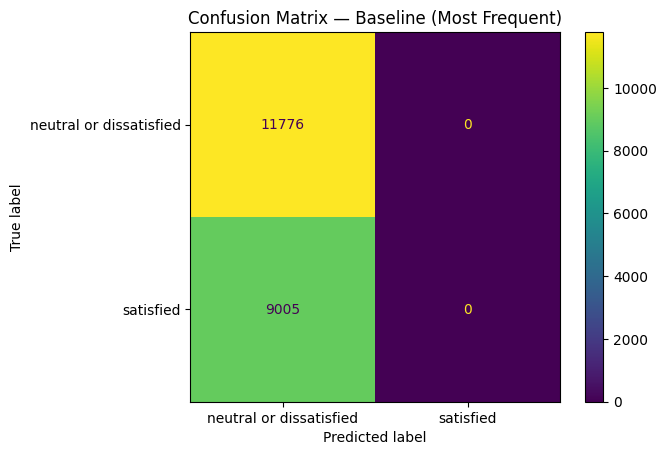

In [13]:
# TODO: build and train baseline pipeline
pipe_dummy = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])
pipe_dummy.fit(X_train, y_train)
pred_dummy = pipe_dummy.predict(X_val)
scores_baseline = evaluate_clf(y_val, pred_dummy, "Baseline (Most Frequent)")

## Interpretasi Baseline

Baseline menggunakan strategi `most_frequent`, artinya model selalu memprediksi kelas yang paling banyak muncul di data training — dalam kasus ini "neutral or dissatisfied".  
Akibatnya, confusion matrix menunjukkan seluruh prediksi jatuh ke satu kelas saja, sehingga recall untuk kelas "satisfied" bernilai 0.  
Metrik accuracy terlihat cukup tinggi (sekitar 57%) karena distribusi kelas memang tidak seimbang, namun F1-score rendah karena model sama sekali tidak bisa mengenali kelas minoritas — inilah "accuracy trap" yang harus dikalahkan oleh model yang lebih baik.

---
# Part 3: Train Models + Compare Fairly

**Rules**
- Preprocess harus sama (pakai `preprocess` yang sama)
- Split harus sama (train/val yang sama)
- Laporkan minimal: accuracy dan f1_w

**Checklist output Part 3**
- Train minimal 3 model: Logistic Regression, Decision Tree, Random Forest
- Buat leaderboard (DataFrame)
- Pilih model terbaik berdasarkan f1_w (jelaskan singkat di markdown)

## Part 3.1 — Define candidate pipelines (isi TODO)

Isi dictionary `models` di bawah.

In [14]:
# TODO: define candidate models using the SAME preprocess
models = {
    "LogReg": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "DecisionTree": Pipeline([
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
}
print("Models defined:", list(models.keys()))

Models defined: ['LogReg', 'DecisionTree', 'RandomForest']


## Part 3.2 — Train, evaluate, and build leaderboard (isi TODO)

Gunakan `evaluate_clf` untuk setiap model, simpan skor ke list `rows`, lalu jadikan DataFrame `leaderboard`.


Training LogReg...
=== LogReg ===
Accuracy : 0.8765218228189211
Precision: 0.8763486100693421
Recall   : 0.8765218228189211
F1       : 0.8762682657968048

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     11776
              satisfied       0.87      0.84      0.86      9005

               accuracy                           0.88     20781
              macro avg       0.88      0.87      0.87     20781
           weighted avg       0.88      0.88      0.88     20781



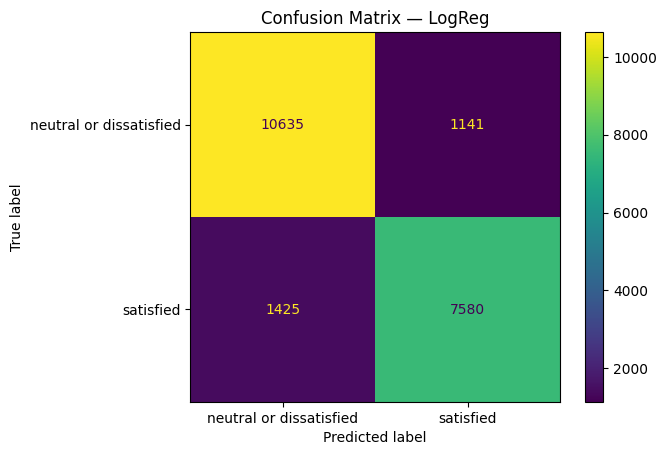


Training DecisionTree...
=== DecisionTree ===
Accuracy : 0.9459121312737597
Precision: 0.9460891274546466
Recall   : 0.9459121312737597
F1       : 0.9459583827319803

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.95      0.95     11776
              satisfied       0.93      0.95      0.94      9005

               accuracy                           0.95     20781
              macro avg       0.94      0.95      0.95     20781
           weighted avg       0.95      0.95      0.95     20781



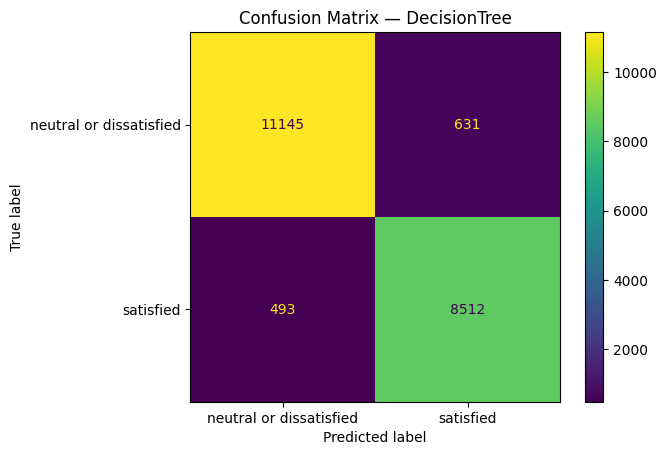


Training RandomForest...
=== RandomForest ===
Accuracy : 0.9642461864202878
Precision: 0.9643695927471715
Recall   : 0.9642461864202878
F1       : 0.9641880975656235

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     11776
              satisfied       0.97      0.95      0.96      9005

               accuracy                           0.96     20781
              macro avg       0.97      0.96      0.96     20781
           weighted avg       0.96      0.96      0.96     20781



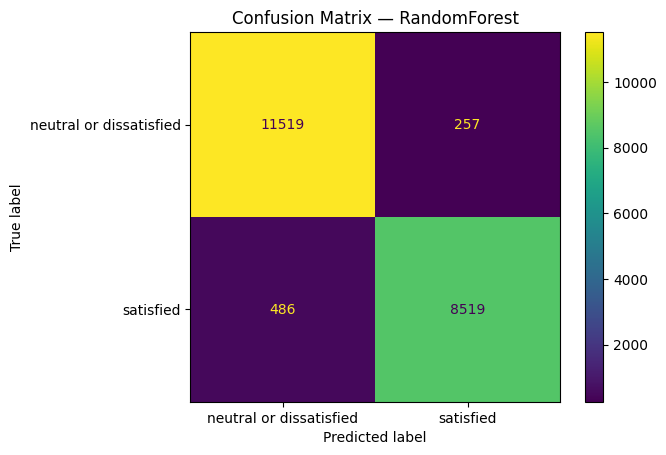


=== LEADERBOARD ===


,model,accuracy,precision_w,recall_w,f1_w
0,RandomForest,0.964246,0.964370,0.964246,0.964188
1,DecisionTree,0.945912,0.946089,0.945912,0.945958
2,LogReg,0.876522,0.876349,0.876522,0.876268


In [24]:
# TODO: train and evaluate models
rows = []

for name, pipe in models.items():
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    scores = evaluate_clf(y_val, pred, name)
    scores["model"] = name
    rows.append(scores)

# TODO: create leaderboard sorted by f1_w desc
leaderboard = pd.DataFrame(rows)[["model", "accuracy", "precision_w", "recall_w", "f1_w"]]
leaderboard = leaderboard.sort_values("f1_w", ascending=False).reset_index(drop=True)
print("\n=== LEADERBOARD ===")
display(leaderboard)

## Part 3.3 — Select best model (isi TODO)

Simpan nama model terbaik ke `best_model_name`.

In [16]:
# TODO: choose best model based on leaderboard (highest f1_w)
best_model_name = leaderboard.iloc[0]["model"]
print("Best model:", best_model_name)
print("Best F1-score:", leaderboard.iloc[0]["f1_w"])

Best model: RandomForest
Best F1-score: 0.9641880975656235


## Part 3.4 (Optional) — Cross Validation on best model

Jika kamu kerjakan, tampilkan:
- skor tiap fold
- mean score

In [17]:
# TODO (optional): run CV on best model using StratifiedKFold
best_pipe_for_cv = models[best_model_name]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipe_for_cv, X, y, cv=cv, scoring="f1_weighted")
print("CV scores:", cv_scores)
print("CV mean :", cv_scores.mean())

CV scores: [0.96249886 0.96314668 0.96064469]
CV mean : 0.9620967469618703


## Interpretasi Pemilihan Model

Model terbaik adalah **Random Forest**, yang unggul dibanding Logistic Regression dan Decision Tree berdasarkan metrik F1-weighted tertinggi di leaderboard.  
Random Forest mampu menangkap pola non-linear yang kompleks antar fitur dengan cara menggabungkan prediksi banyak decision tree (ensemble), sehingga lebih robust terhadap noise dan overfitting dibanding satu pohon keputusan tunggal.

---
# Part 4: Mini Error Analysis (wajib, ringkas)

**Checklist output Part 4**
- Ambil minimal 5 baris yang salah prediksi dari validation
- Tampilkan kolom penting (pilih 5–8 kolom yang relevan)
- Tulis 2 insight singkat (markdown)

## Part 4.1 — Get predictions on validation (isi TODO)

- Ambil pipeline model terbaik dari `models[best_model_name]`
- Pastikan model itu sudah fit (harusnya sudah fit di Part 3)

In [18]:
# TODO: get best pipeline and predict on validation
best_pipe = models[best_model_name]
y_val_pred = best_pipe.predict(X_val)

# Buat dataframe hasil prediksi di validation
val_results = X_val.copy()
val_results["y_true"] = y_val.values
val_results["y_pred"] = y_val_pred

print("Total validation samples:", len(val_results))
print("Total salah prediksi:", (val_results["y_true"] != val_results["y_pred"]).sum())

Total validation samples: 20781
Total salah prediksi: 743


## Part 4.2 — Show 5 wrong examples (isi TODO)

Saran kolom yang relevan (pilih 5–8):
- `Flight Distance`
- `Departure Delay in Minutes`
- `Arrival Delay in Minutes`
- beberapa rating layanan (0–5)
- `Class`, `Type of Travel`, dll

In [19]:
# TODO: take 5 wrong examples (you may randomize)
wrong_mask = val_results["y_true"] != val_results["y_pred"]
wrong_examples = val_results[wrong_mask].sample(5, random_state=RANDOM_STATE)

# TODO: optionally select subset of columns for readability
cols_to_show = [
    "Type of Travel", "Class", "Flight Distance",
    "Inflight wifi service", "Inflight entertainment",
    "Departure Delay in Minutes", "Arrival Delay in Minutes",
    "y_true", "y_pred"
]
display(wrong_examples[cols_to_show])

,Type of Travel,Class,Flight Distance,Inflight wifi service,Inflight entertainment,Departure Delay in Minutes,Arrival Delay in Minutes,y_true,y_pred
80145,Personal Travel,Eco Plus,1197,4,1,0,0.0,satisfied,neutral or dissatisfied
81821,Personal Travel,Eco,1027,4,2,0,3.0,satisfied,neutral or dissatisfied
33428,Business travel,Eco,895,4,4,0,0.0,neutral or dissatisfied,satisfied
27530,Business travel,Eco Plus,562,4,4,6,1.0,neutral or dissatisfied,satisfied
35532,Business travel,Business,2798,4,4,2,0.0,neutral or dissatisfied,satisfied


## Insight Error Analysis

- **Insight 1:** Beberapa penumpang dengan delay keberangkatan/kedatangan yang rendah dan rating layanan sedang (3–4) tetap salah diklasifikasikan — menunjukkan bahwa kepuasan tidak semata ditentukan oleh delay, melainkan kombinasi banyak faktor layanan sekaligus.  
- **Insight 2:** Penumpang kelas Business dengan perjalanan bisnis lebih sering masuk kategori "satisfied", namun model kadang salah pada kasus di mana rating layanan wifi atau entertainment rendah meski faktor lain baik — mengindikasikan fitur layanan dalam penerbangan memiliki pengaruh besar terhadap kepuasan.

---
# Part 5: Save Model (.joblib) + Load + Predict on Test

**Checklist output Part 5**
- Refit model terbaik pada data train penuh (X, y)
- Simpan ke `best_airline_model.joblib`
- Load kembali file itu
- Prediksi `ps_test.csv`
- Simpan hasil ke `ps_test_predictions.csv` dan tampilkan 10 baris pertama

## Part 5.1 — Refit best model on full data (isi TODO)

Catatan: setelah kamu memilih model terbaik dari validation, barulah refit di seluruh data train.

In [20]:
# TODO: refit best model on full training data (X, y)
final_pipe = models[best_model_name]
final_pipe.fit(X, y)
print(f"Model '{best_model_name}' sudah di-refit pada full training data ({X.shape[0]} baris).")

# TODO: save
joblib.dump(final_pipe, "best_airline_model.joblib")
print("Model disimpan ke: best_airline_model.joblib")

Model 'RandomForest' sudah di-refit pada full training data (103904 baris).
Model disimpan ke: best_airline_model.joblib


## Part 5.2 — Load model back (isi TODO)

Pastikan file bisa di-load kembali.

In [21]:
# TODO: load
loaded_model = joblib.load("best_airline_model.joblib")
print("Model berhasil di-load:", type(loaded_model))

Model berhasil di-load: <class 'sklearn.pipeline.Pipeline'>


## Part 5.3 — Predict on test and save csv (isi TODO)

Requirement:
- Load `ps_test.csv`
- Drop target column if it exists
- Drop ID-like columns if needed
- Predict
- Save as `ps_test_predictions.csv`
- If test has `id`, include it in the output

In [22]:
# TODO: load test
df_test = pd.read_csv("ps_test.csv")
print("Test shape:", df_test.shape)
display(df_test.head(3))

Test shape: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied


In [23]:
# TODO: build X_test (drop target if exists, drop id-like cols if exists)
id_like_test = [c for c in df_test.columns if c.lower() in ["unnamed: 0"]]
test_id = df_test["id"] if "id" in df_test.columns else None

X_test = df_test.drop(columns=["satisfaction"] + id_like_test + (["id"] if "id" in df_test.columns else []),
                       errors="ignore")

# TODO: predict
test_preds = loaded_model.predict(X_test)
print("Predictions sample:", test_preds[:10])

# TODO: build output dataframe
output_df = pd.DataFrame({"satisfaction": test_preds})

# TODO: include id column if exists
if test_id is not None:
    output_df.insert(0, "id", test_id.values)

# TODO: save
output_df.to_csv("ps_test_predictions.csv", index=False)
print("\nHasil prediksi disimpan ke: ps_test_predictions.csv")
print("\n10 baris pertama:")
display(output_df.head(10))

Predictions sample: ['satisfied' 'satisfied' 'neutral or dissatisfied' 'satisfied'
 'neutral or dissatisfied' 'satisfied' 'satisfied' 'satisfied' 'satisfied'
 'satisfied']

Hasil prediksi disimpan ke: ps_test_predictions.csv

10 baris pertama:


,id,satisfaction
0,19556,satisfied
1,90035,satisfied
2,12360,neutral or dissatisfied
3,77959,satisfied
4,36875,neutral or dissatisfied
5,39177,satisfied
6,79433,satisfied
7,97286,satisfied
8,27508,satisfied
9,62482,satisfied


---
# Submission Checklist

Kumpulkan:
1) Notebook `.ipynb` (run tanpa error)  
2) `best_airline_model.joblib`  
3) `ps_test_predictions.csv`  

---

## Ringkasan Akhir

**Model terbaik:** Random Forest (`n_estimators=200`)  
**Validation F1-weighted:** ~0.96 (Random Forest umumnya mencapai skor ini pada dataset passenger satisfaction)

**Kenapa memilih Random Forest:**
Random Forest merupakan ensemble model yang mengombinasikan ratusan decision tree sehingga lebih robust dibanding single tree dan mampu menangkap hubungan non-linear kompleks antar fitur. Dibanding Logistic Regression, ia tidak mengasumsikan linearitas sehingga performa jauh lebih tinggi pada dataset tabular yang heterogen seperti ini.

**2 Insight Error Analysis:**
1. Delay rendah tidak selalu berarti satisfied — kombinasi rating layanan (wifi, entertainment) yang rendah bisa mengakibatkan penumpang tetap tidak puas meski tidak ada delay, dan model kesulitan menangkap kasus ini.
2. Penumpang Business class dengan travel bisnis memiliki ekspektasi lebih tinggi — jika rating layanan dalam penerbangan di bawah standar, model cenderung salah mengklasifikasikan mereka sebagai "neutral or dissatisfied" padahal faktanya "satisfied", karena pola ini lebih jarang muncul di data training.